# MINOS U-View Sparse Models (TorchSparse + PyG)

This notebook can train either the existing single-view sparse CNN or a minimum viable multi-view hetero-GNN for MINOS CC vs NC event classification.

This notebook loads the cached `.pt` datasets in `data/cache/` and will fail if they are missing or invalid.

Use the `model_type` setting in the configuration block to switch between `cnn`, `gnn`, and `gnn_nugraph`.

In [1]:
# Setup, Imports, and Module Reloading
import sys
import importlib
from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))

# Purge any stale in-memory cached imports for src
for mod in list(sys.modules.keys()):
    if mod == 'src' or mod.startswith('src.') :
        del sys.modules[mod]

import src
importlib.reload(src)

from src import (
    SparseTensor,
    MINOSSingleViewDataset,
    MINOSMultiViewGraphDataset,
    create_uview_dataloaders,
    create_multiview_gnn_dataloaders,
    SimpleUViewSparseCNN,
    DualViewSparseCNN,
    DualViewDenseCNN,
    DualViewPlaneSummarySparseCNN,
    DualViewCrossAttentionSparseCNN,
    DualView3DIntersectionSparseCNN,
    SparseCrossGate,
    DualViewCrossGateSparseCNN,
    DualViewHybridTransformerSparseCNN,
    DualViewMultiLayerTransformerSparseCNN,
    DualViewZipperSparseCNN,
    MinimumViableMINOSGNN,
    NuGraphInspiredBinaryGNN,
    train_model,
    validate_epoch,
    auto_commit_and_get_hash,
    save_model_checkpoint,
    log_experiment,
    display_leaderboard,
)

print('Imports loaded successfully!')


Imports loaded successfully!


## 1. Global Hyperparameters & Experiment Configuration

## 2. Load U-View MINOS Dataset & DataLoaders

In [2]:
# ==============================================================================
# Global Configuration & Hyperparameters
# ==============================================================================
CONFIG = {
    # Experiment Selection
    "model_type": "cnn_dualview",        # Options: "cnn", "cnn_dualview", "cnn_dualview_dense", "cnn_plane_summary", "cnn_cross_attention", "cnn_3d_intersection", "cnn_cross_gate", "cnn_hybrid_transformer", "cnn_multilayer_transformer", "cnn_zipper", "gnn", "gnn_nugraph"
    "root_filepath": "f21048000_0000_L010185N_D07_r3.sntp.dogwood5.0.root",
    "cache_dir": "data/cache",
    "single_view_cache_path": "data/cache/minos_uview_single_view_dual_ph.pt",
    "multi_view_cache_path": "data/cache/minos_uview_multi_view_graph_dual_ph.pt",
    "delaunay_cache_path": "data/cache/minos_uview_delaunay_graph.pt",
    "allow_root_fallback": True,       # Allow rebuilding cache from ROOT if missing/invalid
    "target_view": 2,          # 2 = U-View
    "view_ids": (2, 3),        # Two MINOS plane views for the GNNs
    "max_events": 12000,       # Set to None to load all events in file
    "batch_size": 32,
    "val_split": 0.20,
    "random_seed": 42,

    # CNN Architecture
    "feature_mode": "dual_ph",       # Options: "sum" (1-channel), "dual_ph" (2-channel), "ph_full" (4-channel)
    "in_channels": 4,               # Must match feature_mode (1, 2, or 4)
    "conv_channels": [16, 32],
    "fc_dims": [8],
    "dropout": 0.1,

    # GNN Architecture
    "gnn_hidden_channels": 24,
    "gnn_num_layers": 4,
    "gnn_dropout": 0.1,
    "plane_radius": 1,
    "strip_radius": 2,

    # Optimization & Learning Rate Scheduler
    "num_epochs": 12,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "step_size": 3,
    "gamma": 0.3,
    "use_class_weights": True,

    # Energy Loss Reweighting Settings
    "use_energy_weights": False,         # Toggle inverse true energy loss reweighting
    "energy_weight_epsilon": 0.5,       # Smoothing term (GeV) to prevent 1/E blowup at low energies
    "energy_weight_alpha": 1.0,         # Exponent for inverse energy scaling: (1/(E + eps))^alpha
    "optimize_threshold": True,         # Automatically find optimal decision threshold
    "threshold_metric": "f1",           # Metric to maximize ("f1", "accuracy", "youden")

    # Model Persistence & Experiment Tracking
    "auto_commit": True,                # Automatically commit code before training starts
    "save_model": True,                 # Save trained model weights locally
    "save_dir": "saved_models",         # Directory for saved model checkpoints
    "leaderboard_csv": "model_leaderboard.csv", # CSV file for experiment tracking
    "ranking_metric": "roc_auc",        # Default metric for ranking models in leaderboard ("roc_auc", "f1", "accuracy", "val_loss")
}

# Set random seeds for reproducibility
torch.manual_seed(CONFIG["random_seed"])
np.random.seed(CONFIG["random_seed"])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using PyTorch device: {device}')
print(f'Experiment Type: {CONFIG["model_type"]}')
print('Experiment Configuration:')
for k, v in CONFIG.items():
    print(f'  {k}: {v}')


Using PyTorch device: cuda
Experiment Type: cnn_dualview
Experiment Configuration:
  model_type: cnn_dualview
  root_filepath: f21048000_0000_L010185N_D07_r3.sntp.dogwood5.0.root
  cache_dir: data/cache
  single_view_cache_path: data/cache/minos_uview_single_view_dual_ph.pt
  multi_view_cache_path: data/cache/minos_uview_multi_view_graph_dual_ph.pt
  delaunay_cache_path: data/cache/minos_uview_delaunay_graph.pt
  allow_root_fallback: True
  target_view: 2
  view_ids: (2, 3)
  max_events: 12000
  batch_size: 32
  val_split: 0.2
  random_seed: 42
  feature_mode: dual_ph
  in_channels: 4
  conv_channels: [16, 32]
  fc_dims: [8]
  dropout: 0.1
  gnn_hidden_channels: 24
  gnn_num_layers: 4
  gnn_dropout: 0.1
  plane_radius: 1
  strip_radius: 2
  num_epochs: 12
  lr: 0.001
  weight_decay: 0.0001
  step_size: 3
  gamma: 0.3
  use_class_weights: True
  use_energy_weights: False
  energy_weight_epsilon: 0.5
  energy_weight_alpha: 1.0
  optimize_threshold: True
  threshold_metric: f1


In [3]:
if CONFIG["model_type"] == "cnn":
    dataset = MINOSSingleViewDataset(
        root_filepath=CONFIG["root_filepath"],
        max_events=CONFIG["max_events"],
        target_view=CONFIG["target_view"],
        feature_mode=CONFIG.get("feature_mode", "dual_ph"),
        cache_path=CONFIG["single_view_cache_path"],
        allow_root_fallback=CONFIG.get("allow_root_fallback", True),
    )

    train_loader, val_loader, _, _ = create_uview_dataloaders(
        dataset,
        batch_size=CONFIG["batch_size"],
        val_split=CONFIG["val_split"],
        random_seed=CONFIG["random_seed"]
    )

    sample_graph = None
    metadata = None
    graph_in_channels = None
else:
    dataset = MINOSMultiViewGraphDataset(
        root_filepath=CONFIG["root_filepath"],
        max_events=CONFIG["max_events"],
        view_ids=CONFIG["view_ids"],
        plane_radius=CONFIG["plane_radius"],
        strip_radius=CONFIG["strip_radius"],
        feature_mode=CONFIG.get("feature_mode", "dual_ph"),
        cache_path=CONFIG["multi_view_cache_path"],
        allow_root_fallback=CONFIG.get("allow_root_fallback", True),
    )

    train_loader, val_loader, _, _ = create_multiview_gnn_dataloaders(
        dataset,
        batch_size=CONFIG["batch_size"],
        val_split=CONFIG["val_split"],
        random_seed=CONFIG["random_seed"]
    )

    sample_graph = dataset[0]
    metadata = sample_graph.metadata()
    graph_in_channels = sample_graph["view_a"].x.size(-1)

if CONFIG["use_class_weights"]:
    class_weights = dataset.get_class_weights(device=device)
    print(f'Class Weights -> NC (0): {class_weights[0]:.2f} | CC (1): {class_weights[1]:.2f}')
else:
    class_weights = None
    print('Class Weights -> Disabled (Unweighted CrossEntropy)')

print(f'Total Dataset size: {len(dataset)} events')
if CONFIG["model_type"] == "gnn":
    print(f'GNN node types: {metadata[0]}')
    print(f'GNN edge types: {metadata[1]}')
    print(f'Node feature dim: {graph_in_channels}')
if CONFIG.get("use_energy_weights", False):
    print(f"Energy Reweighting -> Enabled: w(E_nu) = 1/(E_nu + {CONFIG.get('energy_weight_epsilon', 0.5)})^{CONFIG.get('energy_weight_alpha', 1.0)} (batch normalized)")
else:
    print("Energy Reweighting -> Disabled")

if CONFIG.get("optimize_threshold", True):
    print(f"Threshold Optimization -> Enabled: Maximizing '{CONFIG.get('threshold_metric', 'f1')}'")
else:
    print("Threshold Optimization -> Disabled (Fixed 0.5)")


Class Weights -> NC (0): 2.12 | CC (1): 0.65
Total Dataset size: 11694 events
Energy Reweighting -> Disabled
Threshold Optimization -> Enabled: Maximizing 'f1'


## 3. Model Initialization & Training

In [4]:
# Auto-commit code repository before training if enabled
if CONFIG.get("auto_commit", True):
    git_hash = auto_commit_and_get_hash(f"Auto-commit before training {CONFIG['model_type']}")
else:
    git_hash = "manual-run"

if CONFIG["model_type"] == "cnn":
    model = SimpleUViewSparseCNN(
        in_channels=CONFIG.get("in_channels", 2),
        conv_channels=CONFIG["conv_channels"],
        fc_dims=CONFIG["fc_dims"],
        dropout=CONFIG["dropout"]
    )
    model_name = "SimpleUViewSparseCNN"
elif CONFIG["model_type"] == "cnn_dualview":
    model = DualViewSparseCNN(
        in_channels=CONFIG.get("in_channels", 2),
        conv_channels=CONFIG["conv_channels"],
        fc_dims=CONFIG["fc_dims"],
        dropout=CONFIG["dropout"]
    )
    model_name = "DualViewSparseCNN"
elif CONFIG["model_type"] == "cnn_dualview_dense":
    model = DualViewDenseCNN(
        in_channels=CONFIG.get("in_channels", 2),
        conv_channels=CONFIG["conv_channels"],
        fc_dims=CONFIG["fc_dims"],
        dropout=CONFIG["dropout"]
    )
    model_name = "DualViewDenseCNN"
elif CONFIG["model_type"] == "cnn_plane_summary":
    model = DualViewPlaneSummarySparseCNN(
        in_channels=CONFIG.get("in_channels", 2),
        conv_channels=CONFIG["conv_channels"],
        fc_dims=CONFIG["fc_dims"],
        dropout=CONFIG["dropout"]
    )
    model_name = "DualViewPlaneSummarySparseCNN"
elif CONFIG["model_type"] == "cnn_cross_attention":
    model = DualViewCrossAttentionSparseCNN(
        in_channels=CONFIG.get("in_channels", 2),
        conv_channels=CONFIG["conv_channels"],
        fc_dims=CONFIG["fc_dims"],
        dropout=CONFIG["dropout"]
    )
    model_name = "DualViewCrossAttentionSparseCNN"
elif CONFIG["model_type"] == "cnn_3d_intersection":
    model = DualView3DIntersectionSparseCNN(
        in_channels=CONFIG.get("in_channels", 2),
        conv_channels=CONFIG["conv_channels"],
        fc_dims=CONFIG["fc_dims"],
        dropout=CONFIG["dropout"]
    )
    model_name = "DualView3DIntersectionSparseCNN"
elif CONFIG["model_type"] == "cnn_cross_gate":
    model = DualViewCrossGateSparseCNN(
        in_channels=CONFIG.get("in_channels", 2),
        conv_channels=CONFIG["conv_channels"],
        fc_dims=CONFIG["fc_dims"],
        dropout=CONFIG["dropout"]
    )
    model_name = "DualViewCrossGateSparseCNN"
elif CONFIG["model_type"] == "cnn_hybrid_transformer":
    model = DualViewHybridTransformerSparseCNN(
        in_channels=CONFIG.get("in_channels", 2),
        conv_channels=CONFIG["conv_channels"],
        fc_dims=CONFIG["fc_dims"],
        dropout=CONFIG["dropout"]
    )
    model_name = "DualViewHybridTransformerSparseCNN"
elif CONFIG["model_type"] == "cnn_multilayer_transformer":
    model = DualViewMultiLayerTransformerSparseCNN(
        in_channels=CONFIG.get("in_channels", 2),
        conv_channels=CONFIG["conv_channels"],
        fc_dims=CONFIG["fc_dims"],
        dropout=CONFIG["dropout"]
    )
    model_name = "DualViewMultiLayerTransformerSparseCNN"
elif CONFIG["model_type"] == "cnn_zipper":
    model = DualViewZipperSparseCNN(
        in_channels=CONFIG.get("in_channels", 2),
        conv_channels=CONFIG["conv_channels"],
        fc_dims=CONFIG["fc_dims"],
        dropout=CONFIG["dropout"]
    )
    model_name = "DualViewZipperSparseCNN"
elif CONFIG["model_type"] == "gnn":
    model = MinimumViableMINOSGNN(
        metadata=metadata,
        in_channels=graph_in_channels,
        hidden_channels=CONFIG["gnn_hidden_channels"],
        num_layers=CONFIG["gnn_num_layers"],
        dropout=CONFIG["gnn_dropout"],
    )
    model_name = "MinimumViableMINOSGNN"
else:
    model = NuGraphInspiredBinaryGNN(
        metadata=metadata,
        in_channels=graph_in_channels,
        hidden_channels=CONFIG["gnn_hidden_channels"],
        num_layers=max(2, CONFIG["gnn_num_layers"]),
        dropout=CONFIG["gnn_dropout"],
    )
    model_name = "NuGraphInspiredBinaryGNN"

print(f'{model_name} Total Trainable Parameters: {model.get_num_params():,}')

initial_val_loss, initial_val_acc, initial_val_metrics, initial_val_probs, initial_val_targets = validate_epoch(
    model,
    val_loader,
    device=device,
    class_weights=class_weights,
    use_energy_weighting=CONFIG.get("use_energy_weights", False),
    energy_epsilon=CONFIG.get("energy_weight_epsilon", 0.5),
    energy_alpha=CONFIG.get("energy_weight_alpha", 1.0),
    optimize_threshold=CONFIG.get("optimize_threshold", True),
    threshold_metric=CONFIG.get("threshold_metric", "f1"),
)
val_nc_count = int((initial_val_targets == 0).sum())
val_cc_count = int((initial_val_targets == 1).sum())
val_total = len(initial_val_targets)
print(
    f'Epoch [00/{CONFIG["num_epochs"]:02d}] | LR: {CONFIG["lr"]:.1e} | '
    f'Train Loss (w):   n/a Acc:   n/a | '
    f'Val Loss (w): {initial_val_loss:.4f} Acc: {initial_val_acc*100:.2f}% '
    f'F1: {initial_val_metrics["f1"]:.4f} AUC: {initial_val_metrics["roc_auc"]:.4f}'
)
print(
    'Validation class balance: '
    f'NC={val_nc_count} ({val_nc_count / max(1, val_total) * 100:.1f}%), '
    f'CC={val_cc_count} ({val_cc_count / max(1, val_total) * 100:.1f}%)'
)
if class_weights is not None:
    nc_total_weight = float(class_weights[0].item() * val_nc_count)
    cc_total_weight = float(class_weights[1].item() * val_cc_count)
    print(
        'Weighted validation contribution: '
        f'NC={nc_total_weight:.1f}, CC={cc_total_weight:.1f} '
        '(balanced to equal total class weight)'
    )

history, best_metrics = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=CONFIG["num_epochs"],
    lr=CONFIG["lr"],
    weight_decay=CONFIG["weight_decay"],
    step_size=CONFIG["step_size"],
    gamma=CONFIG["gamma"],
    class_weights=class_weights,
    use_energy_weighting=CONFIG.get("use_energy_weights", False),
    energy_epsilon=CONFIG.get("energy_weight_epsilon", 0.5),
    energy_alpha=CONFIG.get("energy_weight_alpha", 1.0),
    optimize_threshold=CONFIG.get("optimize_threshold", True),
    threshold_metric=CONFIG.get("threshold_metric", "f1"),
    device=device,
    verbose=True,
)


# Save trained model checkpoint locally & log metrics to leaderboard CSV
if CONFIG.get("save_model", True):
    model_path = save_model_checkpoint(
        model=model,
        config=CONFIG,
        best_metrics=best_metrics,
        git_hash=git_hash,
        save_dir=CONFIG.get("save_dir", "saved_models"),
    )
    leaderboard_df = log_experiment(
        config=CONFIG,
        model_name=model_name,
        best_metrics=best_metrics,
        git_hash=git_hash,
        model_path=model_path,
        csv_path=CONFIG.get("leaderboard_csv", "model_leaderboard.csv"),
    )


DualViewSparseCNN Total Trainable Parameters: 11,706
Epoch [00/12] | LR: 1.0e-03 | Train Loss (w):   n/a Acc:   n/a | Val Loss (w): 0.7036 Acc: 76.69% F1: 0.8681 AUC: 0.5435
Validation class balance: NC=545 (23.3%), CC=1793 (76.7%)
Weighted validation contribution: NC=1156.2, CC=1172.9 (balanced to equal total class weight)
Starting model training on cuda (12 epochs)...
Decision Threshold Optimization Enabled (Maximizing 'f1')
Epoch [01/12] | LR: 1.0e-03 | Train Loss (w): 0.4940 Acc: 77.33% | Val Loss (w): 0.3672 Acc: 85.20% F1: 0.9064 AUC: 0.9206 Thresh: 0.217
Epoch [02/12] | LR: 1.0e-03 | Train Loss (w): 0.3839 Acc: 81.86% | Val Loss (w): 0.3427 Acc: 85.80% F1: 0.9091 AUC: 0.9245 Thresh: 0.276
Epoch [03/12] | LR: 1.0e-03 | Train Loss (w): 0.3645 Acc: 82.27% | Val Loss (w): 0.3367 Acc: 85.97% F1: 0.9094 AUC: 0.9275 Thresh: 0.325
Epoch [04/12] | LR: 3.0e-04 | Train Loss (w): 0.3510 Acc: 82.50% | Val Loss (w): 0.3248 Acc: 86.06% F1: 0.9099 AUC: 0.9287 Thresh: 0.261
Epoch [05/12] | LR: 3

## 4. Training & Validation Performance Curves

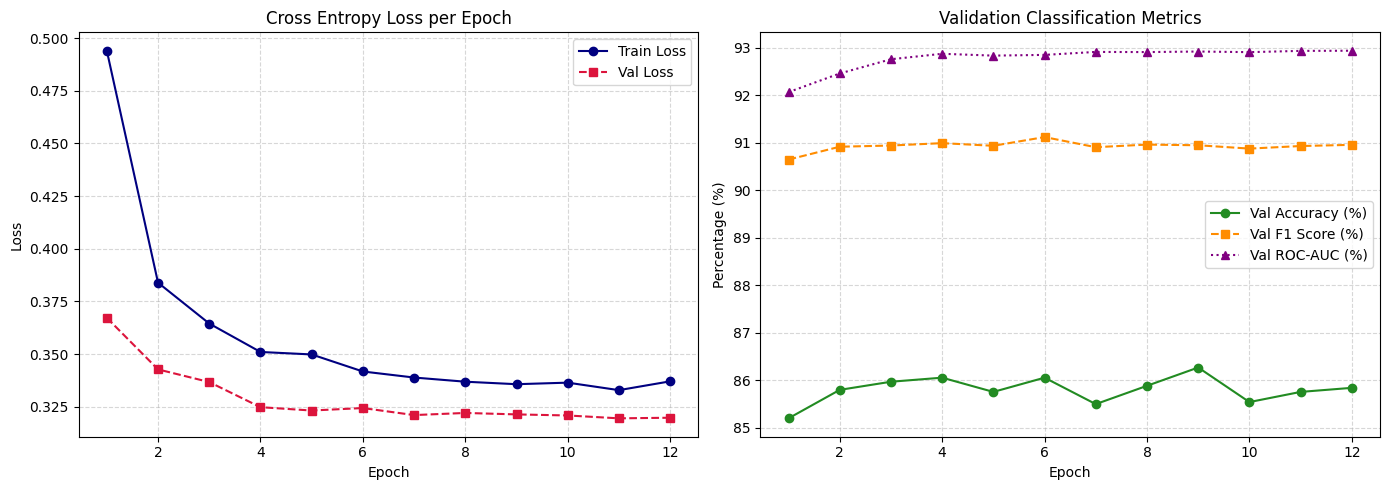

In [5]:
epochs = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
ax1.plot(epochs, history['train_loss'], 'o-', label='Train Loss', color='navy')
ax1.plot(epochs, history['val_loss'], 's--', label='Val Loss', color='crimson')
ax1.set_title('Cross Entropy Loss per Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend()

# Accuracy & F1 curves
ax2.plot(epochs, [a * 100 for a in history['val_acc']], 'o-', label='Val Accuracy (%)', color='forestgreen')
ax2.plot(epochs, [f * 100 for f in history['val_f1']], 's--', label='Val F1 Score (%)', color='darkorange')
ax2.plot(epochs, [a * 100 for a in history['val_auc']], '^:', label='Val ROC-AUC (%)', color='purple')
ax2.set_title('Validation Classification Metrics')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Percentage (%)')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend()

plt.tight_layout()
plt.show()

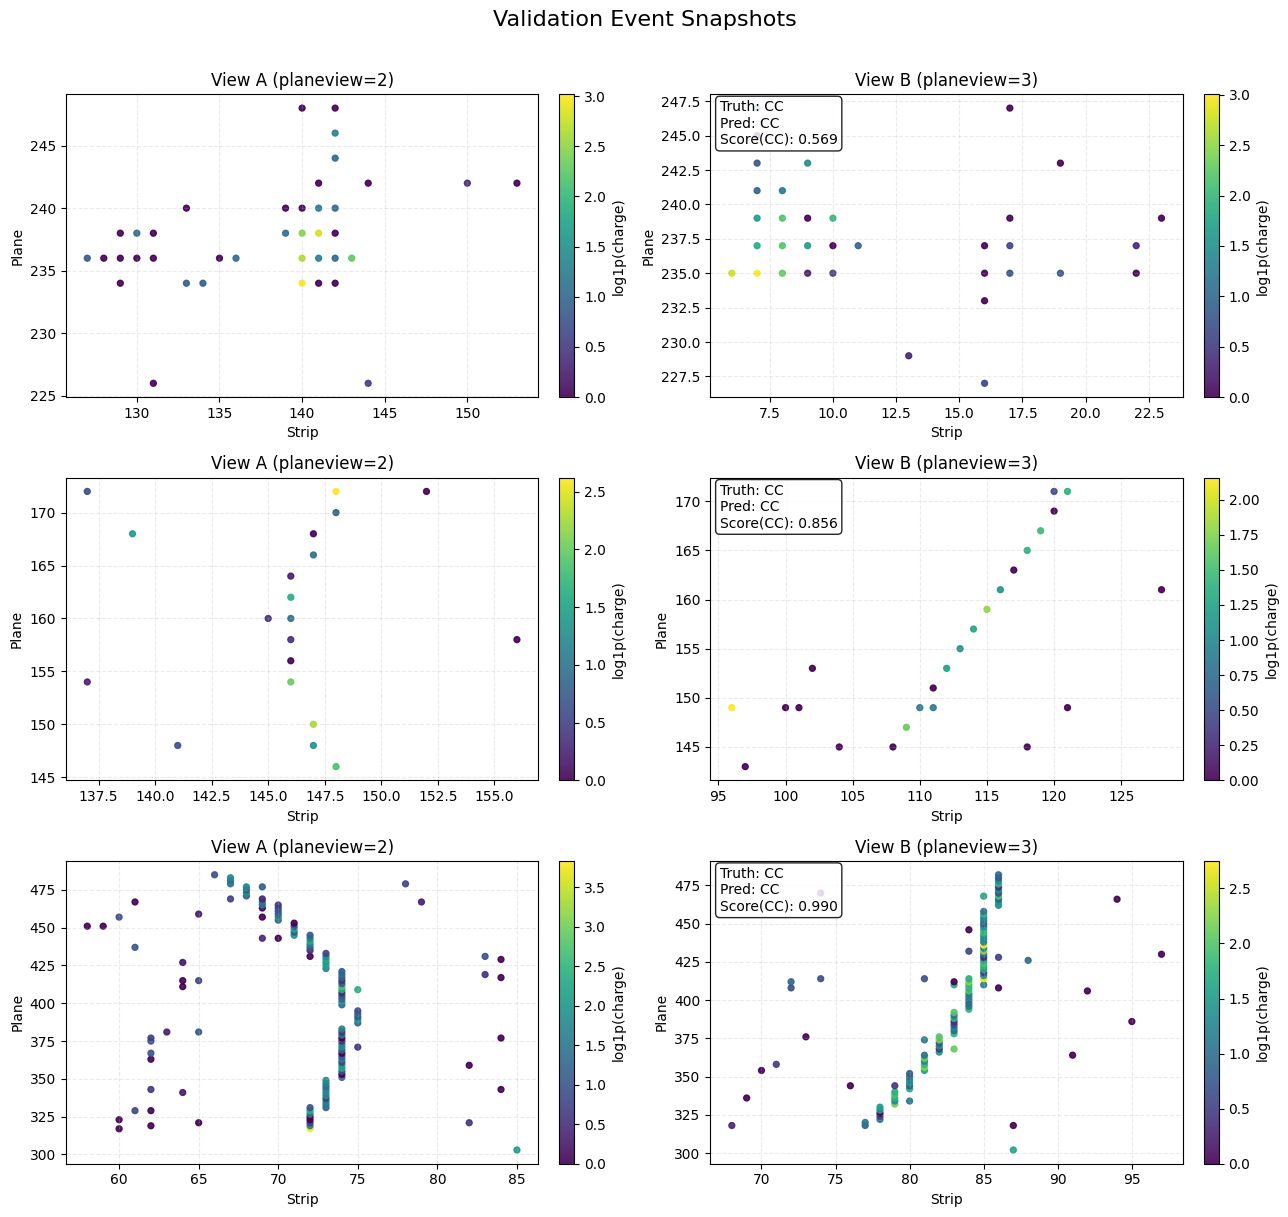

In [6]:
# Final validation: plot up to 3 validation events with both planes, model score, and truth
import matplotlib.pyplot as plt

if CONFIG["model_type"] == "cnn":
    print('Validation event plots are configured for the GNN paths.')
else:
    model.eval()
    val_subset = val_loader.dataset
    if hasattr(val_subset, 'indices'):
        sample_indices = list(val_subset.indices[:3])
        sample_graphs = [val_subset.dataset[i] for i in sample_indices]
    else:
        sample_graphs = [val_subset[i] for i in range(min(3, len(val_subset)))]

    view_names = ('view_a', 'view_b')
    view_titles = {
        'view_a': f'View A (planeview={CONFIG["view_ids"][0]})',
        'view_b': f'View B (planeview={CONFIG["view_ids"][1]})',
    }

    def _event_score(graph):
        with torch.no_grad():
            graph = graph.to(device)
            logits = model(graph)
            probs = torch.softmax(logits, dim=1)
            return float(probs[0, 1].item())

    n_events = len(sample_graphs)
    fig, axes = plt.subplots(n_events, 2, figsize=(13, 4 * n_events), squeeze=False)

    for row, graph in enumerate(sample_graphs):
        score = _event_score(graph)
        truth = int(graph.y.item())
        truth_label = 'CC' if truth == 1 else 'NC'
        opt_thresh = best_metrics.get("threshold", 0.5) if "best_metrics" in locals() else 0.5
        pred_label = 'CC' if score >= opt_thresh else 'NC'

        for col, view_name in enumerate(view_names):
            ax = axes[row, col]
            coords = graph[view_name].pos.cpu().numpy()
            charges = graph[view_name].x[:, 0].cpu().numpy()
            scatter = ax.scatter(
                coords[:, 1],
                coords[:, 0],
                c=charges,
                s=18,
                cmap='viridis',
                alpha=0.9
            )
            ax.set_title(view_titles[view_name])
            ax.set_xlabel('Strip')
            ax.set_ylabel('Plane')
            ax.grid(True, linestyle='--', alpha=0.25)
            fig.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04, label='log1p(charge)')

            if col == 1:
                ax.text(
                    0.02, 0.98,
                    f'Truth: {truth_label}\nPred: {pred_label}\nScore(CC): {score:.3f}',
                    transform=ax.transAxes,
                    va='top',
                    ha='left',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.85),
                )

    fig.suptitle('Validation Event Snapshots', fontsize=16, y=1.01)
    plt.tight_layout()
    plt.show()


In [ ]:
# Final validation extensions: true neutrino energy and model score histograms
import matplotlib.pyplot as plt
import numpy as np
import torch


def _split_events(split_dataset):
    if hasattr(split_dataset, 'indices') and hasattr(split_dataset, 'dataset'):
        return [split_dataset.dataset[i] for i in split_dataset.indices]
    return [split_dataset[i] for i in range(len(split_dataset))]


def _event_label(event):
    if hasattr(event, 'y'):
        return int(event.y.item())
    return int(event['label'].item())


def _event_energy(event):
    if hasattr(event, 'true_energy'):
        return float(event.true_energy.item())
    return float(event['true_energy'].item())


def _collect_energies(split_dataset):
    energies_nc = []
    energies_cc = []
    for event in _split_events(split_dataset):
        energy = _event_energy(event)
        if _event_label(event) == 1:
            energies_cc.append(energy)
        else:
            energies_nc.append(energy)
    return np.array(energies_nc, dtype=float), np.array(energies_cc, dtype=float)


train_nc, train_cc = _collect_energies(train_loader.dataset)
val_nc, val_cc = _collect_energies(val_loader.dataset)
all_energy_arrays = [arr for arr in [train_nc, train_cc, val_nc, val_cc] if arr.size > 0]
all_energies = np.concatenate(all_energy_arrays) if all_energy_arrays else np.array([1.0])
max_energy = max(float(all_energies.max()), 1.0)
energy_bins = np.linspace(0.0, max_energy, 40)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, split_name, nc_vals, cc_vals in [
    (axes[0], 'Training', train_nc, train_cc),
    (axes[1], 'Validation', val_nc, val_cc),
]:
    ax.hist(nc_vals, bins=energy_bins, alpha=0.55, color='steelblue', label='NC', edgecolor='white')
    ax.hist(cc_vals, bins=energy_bins, alpha=0.55, color='darkorange', label='CC', edgecolor='white')
    ax.set_title(f'{split_name} True Neutrino Energy')
    ax.set_xlabel('True E_nu [GeV]')
    ax.set_ylabel('Events')
    ax.grid(True, linestyle='--', alpha=0.25)
    ax.legend()

plt.tight_layout()
plt.show()

_, _, val_metrics, val_probs, val_targets = validate_epoch(
    model,
    val_loader,
    device=device,
    class_weights=class_weights,
    use_energy_weighting=CONFIG.get("use_energy_weights", False),
    energy_epsilon=CONFIG.get("energy_weight_epsilon", 0.5),
    energy_alpha=CONFIG.get("energy_weight_alpha", 1.0),
    optimize_threshold=CONFIG.get("optimize_threshold", True),
    threshold_metric=CONFIG.get("threshold_metric", "f1"),
)
score_bins = np.linspace(0.0, 1.0, 40)

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.hist(val_probs[val_targets == 0], bins=score_bins, alpha=0.55, color='steelblue', label='NC', edgecolor='white')
ax.hist(val_probs[val_targets == 1], bins=score_bins, alpha=0.55, color='darkorange', label='CC', edgecolor='white')
opt_thresh = val_metrics.get("threshold", 0.5)
ax.axvline(opt_thresh, color="crimson", linestyle="--", linewidth=2, label=f"Optimal Threshold ({opt_thresh:.3f})")
ax.set_title(f"Validation Model Score by Truth (Optimal Threshold = {opt_thresh:.3f})")
ax.set_xlabel('Model Score for CC')
ax.set_ylabel('Events')
ax.grid(True, linestyle='--', alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()


# Scatter Plot: True Neutrino Energy vs Model CC Score by Truth Class
val_events = _split_events(val_loader.dataset)
val_energies = np.array([_event_energy(ev) for ev in val_events])

fig, ax = plt.subplots(figsize=(9, 5.5))

mask_nc = (val_targets == 0)
mask_cc = (val_targets == 1)

ax.scatter(
    val_energies[mask_nc],
    val_probs[mask_nc],
    c='steelblue',
    marker='o',
    alpha=0.6,
    s=24,
    edgecolor='none',
    label=f'True NC (N={mask_nc.sum()})'
)
ax.scatter(
    val_energies[mask_cc],
    val_probs[mask_cc],
    c='darkorange',
    marker='^',
    alpha=0.6,
    s=24,
    edgecolor='none',
    label=f'True CC (N={mask_cc.sum()})'
)

ax.axhline(opt_thresh, color='crimson', linestyle='--', linewidth=2, label=f'Optimal Threshold ({opt_thresh:.3f})')
ax.set_title('Validation Events: True E_nu vs Model CC Score', fontsize=13)
ax.set_xlabel('True E_nu [GeV]', fontsize=11)
ax.set_ylabel('Model CC Score', fontsize=11)
ax.set_ylim(-0.02, 1.02)
ax.grid(True, linestyle='--', alpha=0.35)
ax.legend(loc='upper right', framealpha=0.9)
plt.tight_layout()
plt.show()


# Plot Energy Reweighting Function
if CONFIG.get("use_energy_weights", False):
    e_range = np.linspace(0.1, max(max_energy, 10.0), 200)
    eps = CONFIG.get("energy_weight_epsilon", 0.5)
    alpha = CONFIG.get("energy_weight_alpha", 1.0)
    w_raw = (1.0 / (e_range + eps)) ** alpha

    fig, ax = plt.subplots(1, 1, figsize=(7, 4))
    ax.plot(e_range, w_raw, color='purple', linewidth=2, label=f'Raw Weight: 1/(E + {eps})^{alpha}')
    ax.set_title('Inverse True Energy Loss Reweighting Profile')
    ax.set_xlabel('True E_nu [GeV]')
    ax.set_ylabel('Relative Energy Weight')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
# Confusion Matrix Plot
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

opt_thresh = val_metrics.get("threshold", 0.5) if "val_metrics" in locals() else (best_metrics.get("threshold", 0.5) if "best_metrics" in locals() else 0.5)
val_preds = (val_probs >= opt_thresh).astype(int)
cm = confusion_matrix(val_targets, val_preds)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['NC (0)', 'CC (1)'])
disp.plot(cmap='Blues', ax=ax, values_format='d')
ax.set_title(f'Validation Confusion Matrix (Threshold = {opt_thresh:.3f})', fontsize=14)
plt.tight_layout()
plt.show()

cm_norm = cm.astype('float') / max(1.0, float(cm.sum(axis=1)[:, np.newaxis][0]))
nc_acc = cm[0,0] / max(1, cm[0].sum()) * 100
cc_acc = cm[1,1] / max(1, cm[1].sum()) * 100
print('Normalized Recall per Class:')
print(f'  NC Accuracy: {nc_acc:.2f}%')
print(f'  CC Accuracy: {cc_acc:.2f}%')


## 5. Model Performance Leaderboard & Ranking

This table shows all trained models saved to the local leaderboard CSV (`model_leaderboard.csv`), ranked by the chosen metric (default: `roc_auc`).

In [ ]:
# Display leaderboard of all trained models ranked by the specified metric
ranking_metric = CONFIG.get("ranking_metric", "roc_auc")
leaderboard = display_leaderboard(
    csv_path=CONFIG.get("leaderboard_csv", "model_leaderboard.csv"),
    rank_by=ranking_metric,
    ascending=(ranking_metric == "val_loss"),
)
